# ARTI 402 — Deep Learning
## Lab 6 — Regularization: Closing the Gap

**Student:**Faisal Abdullah Alshehri  
**Student ID:** 2240001737

**Week 6 · Optimization Algorithms (cont.)**
Regularization techniques: dropout, L1 and L2 regularization; batch normalization and weight
initialization strategies.

| | |
|---|---|
| **Prerequisites** | Lab 5 — backprop, `Layer_Dense`, Adam, the training loop |
| **Reference** | NNFS **Ch. 14–15** |


---

### How to work through the notebook

* Sections are labelled **Idea** (read and run), **Exercise** (you write code) and **Checkpoint** (a short answer).
* Every exercise cell is marked `# TODO`. Do not delete the cells above it — later cells depend on them.
* Run cells **in order**, top to bottom. If something breaks, restart the kernel and run all.
* The graded **Assessment** is at the very end.

---

### Last week ended on an uncomfortable number

Lab 5 finished with the best optimizer reaching about **0.97 on the training data and 0.82 on data
it had never seen.** The network had partly **memorised** its training examples instead of learning
the shape of the problem.

That is **overfitting**, and it is the single most common failure in applied deep learning. A model
that scores brilliantly on data you already have the answers for is worth nothing.

Today we make that gap smaller. Four tools, in order of how much you will build:

| Tool | What it does | You will |
|---|---|---|
| **L2** | penalises large weights | build it |
| **L1** | pushes weights to exactly zero | build it |
| **Dropout** | randomly switches neurons off while training | build it |
| **Weight initialisation** | starts the network at a sensible scale | measure it |
| **Batch normalisation** | re-centres activations inside the network | build the forward pass |

### By the end of this lab you should be able to

1. Split data properly into **training, validation and test**, and say what each is for.
2. Recognise overfitting from a loss curve, not just from a final number.
3. Implement **L1 and L2** penalties in both the loss and the gradient.
4. Implement **dropout**, and explain why it must be switched off at test time.
5. Explain why weight initialisation matters, and what **batch normalisation** does.
6. Accept the central trade: a regularised model fits the training data **worse** on purpose.


---
## Setup

Put `arti402_figures.py` in the **same folder** as this notebook (this is the updated version — it
replaces Lab 5's).

The cell below carries forward Lab 5: the spiral data, the backprop layers and Adam. Two things
are new. `Layer_Dense` now accepts **regularizer strengths**, and the network keeps a
`training` flag, because dropout must behave differently at test time.


In [1]:
import sys, time
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)


def spiral_data(samples, classes, seed=0):
    rng = np.random.RandomState(seed)
    X = np.zeros((samples * classes, 2))
    y = np.zeros(samples * classes, dtype="uint8")
    for c in range(classes):
        ix = range(samples * c, samples * (c + 1))
        r = np.linspace(0.0, 1, samples)
        t = np.linspace(c * 4, (c + 1) * 4, samples) + rng.randn(samples) * 0.2
        X[ix] = np.c_[r * np.sin(t * 2.5), r * np.cos(t * 2.5)]
        y[ix] = c
    return X, y


class Layer_Dense:
    """Lab 5's layer, plus optional L1 / L2 regularizer strengths."""

    def __init__(self, n_inputs, n_neurons,
                 weight_regularizer_l1=0.0, weight_regularizer_l2=0.0,
                 bias_regularizer_l1=0.0, bias_regularizer_l2=0.0):
        self.weights = 0.01 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))
        self.weight_regularizer_l1 = weight_regularizer_l1
        self.weight_regularizer_l2 = weight_regularizer_l2
        self.bias_regularizer_l1 = bias_regularizer_l1
        self.bias_regularizer_l2 = bias_regularizer_l2

    def forward(self, inputs):
        self.inputs = inputs
        self.output = np.dot(inputs, self.weights) + self.biases

    def backward(self, dvalues):
        self.dweights = np.dot(self.inputs.T, dvalues)
        self.dbiases = np.sum(dvalues, axis=0, keepdims=True)
        add_regularizer_gradients(self)          # you write this in Exercise 2
        self.dinputs = np.dot(dvalues, self.weights.T)


def add_regularizer_gradients(layer):
    """Placeholder: does nothing until you write the real one in Exercise 2."""
    pass


class Activation_ReLU:
    def forward(self, inputs):
        self.inputs = inputs
        self.output = np.maximum(0, inputs)

    def backward(self, dvalues):
        self.dinputs = dvalues.copy()
        self.dinputs[self.inputs <= 0] = 0


class Activation_Softmax_Loss_CategoricalCrossentropy:
    def forward(self, inputs, y_true):
        exp = np.exp(inputs - np.max(inputs, axis=1, keepdims=True))
        self.output = exp / np.sum(exp, axis=1, keepdims=True)
        clipped = np.clip(self.output, 1e-7, 1 - 1e-7)
        return np.mean(-np.log(clipped[range(len(clipped)), y_true]))

    def backward(self, dvalues, y_true):
        n = len(dvalues)
        self.dinputs = dvalues.copy()
        self.dinputs[range(n), y_true] -= 1
        self.dinputs = self.dinputs / n


class Optimizer_Adam:
    def __init__(self, learning_rate=0.02, decay=5e-7, epsilon=1e-7,
                 beta_1=0.9, beta_2=0.999):
        self.learning_rate = learning_rate
        self.current_learning_rate = learning_rate
        self.decay = decay; self.epsilon = epsilon
        self.beta_1 = beta_1; self.beta_2 = beta_2
        self.iterations = 0

    def pre_update_params(self):
        if self.decay:
            self.current_learning_rate = self.learning_rate / (1 + self.decay * self.iterations)

    def update_params(self, layer):
        if not hasattr(layer, "weight_cache"):
            layer.weight_momentums = np.zeros_like(layer.weights)
            layer.weight_cache = np.zeros_like(layer.weights)
            layer.bias_momentums = np.zeros_like(layer.biases)
            layer.bias_cache = np.zeros_like(layer.biases)
        t = self.iterations + 1
        layer.weight_momentums = self.beta_1 * layer.weight_momentums + (1 - self.beta_1) * layer.dweights
        layer.bias_momentums = self.beta_1 * layer.bias_momentums + (1 - self.beta_1) * layer.dbiases
        layer.weight_cache = self.beta_2 * layer.weight_cache + (1 - self.beta_2) * layer.dweights ** 2
        layer.bias_cache = self.beta_2 * layer.bias_cache + (1 - self.beta_2) * layer.dbiases ** 2
        layer.weights += -self.current_learning_rate * (layer.weight_momentums / (1 - self.beta_1 ** t)) \
            / (np.sqrt(layer.weight_cache / (1 - self.beta_2 ** t)) + self.epsilon)
        layer.biases += -self.current_learning_rate * (layer.bias_momentums / (1 - self.beta_1 ** t)) \
            / (np.sqrt(layer.bias_cache / (1 - self.beta_2 ** t)) + self.epsilon)

    def post_update_params(self):
        self.iterations += 1


# ---------- the data: a small training set, a big validation set ----------
X_train, y_train = spiral_data(samples=40,  classes=3, seed=0)   # only 40 per class
X_val,   y_val   = spiral_data(samples=100, classes=3, seed=2)
X_test,  y_test  = spiral_data(samples=100, classes=3, seed=1)   # untouched until the end

print("Python :", sys.version.split()[0])
print("train:", X_train.shape, " validation:", X_val.shape, " test:", X_test.shape)
print("\nSetup OK")

Python : 3.9.6
train: (120, 2)  validation: (300, 2)  test: (300, 2)

Setup OK


In [2]:
from arti402_figures_Lab6 import (draw_overfitting_curves, draw_weight_histograms,
                             draw_init_depth, draw_batchnorm_effect,
                             draw_decision_boundaries, draw_spiral_data)

print("figure helpers loaded")

figure helpers loaded


---
---
# Stage 1 · See the problem

## Idea 1 — Overfitting, in the browser and in a curve

### Do this now (8 minutes)

Open the **[TensorFlow Playground](https://playground.tensorflow.org)** again.

1. Pick the **spiral** dataset.
2. Drag **Ratio of training to test data** down to about **20%**, and push **Noise** up to about **30**.
   You have just made the problem hard: little data, and it is messy.
3. Set **Regularization** to **None**, press play, and let it run.
   Watch the two numbers at the top right. **Training loss** keeps falling. **Test loss** stops
   falling and starts **rising**.
4. Now set **Regularization** to **L2** with rate **0.01** and run it again.

### What you should have seen

Without regularization the network keeps improving on the data it can see while getting *worse* on
data it cannot. The background colours grow strange islands that wrap around individual dots.

With L2 the boundary becomes smoother and the two losses stay closer together.

### The same thing in our own network

Our setup today is deliberately harsh: **only 40 samples per class**, but **128 hidden neurons**.
A big network with very little data is exactly when memorising becomes tempting.


In [3]:
def make_network(hidden=128, l1=0.0, l2=0.0, dropout_rate=0.0, seed=0):
    """Build the network for this lab. Returns a dict of its parts."""
    np.random.seed(seed)
    net = {
        "dense1": Layer_Dense(2, hidden, weight_regularizer_l1=l1, weight_regularizer_l2=l2,
                              bias_regularizer_l1=l1, bias_regularizer_l2=l2),
        "relu": Activation_ReLU(),
        "dropout": Layer_Dropout(dropout_rate) if dropout_rate > 0 else None,
        "dense2": Layer_Dense(hidden, 3),
        "loss_activation": Activation_Softmax_Loss_CategoricalCrossentropy(),
    }
    return net


def forward(net, X, y, training=True):
    """Returns the data loss. `training` controls dropout."""
    net["dense1"].forward(X)
    net["relu"].forward(net["dense1"].output)
    h = net["relu"].output
    if net["dropout"] is not None:
        net["dropout"].forward(h, training)
        h = net["dropout"].output
    net["dense2"].forward(h)
    return net["loss_activation"].forward(net["dense2"].output, y)


def backward(net, y):
    net["loss_activation"].backward(net["loss_activation"].output, y)
    net["dense2"].backward(net["loss_activation"].dinputs)
    d = net["dense2"].dinputs
    if net["dropout"] is not None:
        net["dropout"].backward(d)
        d = net["dropout"].dinputs
    net["relu"].backward(d)
    net["dense1"].backward(net["relu"].dinputs)


def train(net, optimizer, epochs=4000, log_every=100):
    """Train, recording (epoch, train loss, train acc, val loss, val acc)."""
    history = []
    for epoch in range(epochs + 1):
        forward(net, X_train, y_train, training=True)
        backward(net, y_train)
        optimizer.pre_update_params()
        optimizer.update_params(net["dense1"])
        optimizer.update_params(net["dense2"])
        optimizer.post_update_params()
        if epoch % log_every == 0:
            tl, ta = evaluate(net, X_train, y_train)      # you write evaluate in Exercise 1
            vl, va = evaluate(net, X_val, y_val)
            history.append((epoch, tl, ta, vl, va))
    return history


print("network, training loop and helpers ready")

network, training loop and helpers ready


---
---
# Stage 2 · Measure it properly

## Idea 2 — Three sets, three jobs

Up to now we have used two sets, and in Lab 5 we even compared optimizers on the **test** set.
That is a bad habit, and here is the fix.

| set | used for | how often you look |
|---|---|---|
| **training** | adjusting the weights | constantly |
| **validation** | choosing settings — learning rate, how much regularization, when to stop | often |
| **test** | the final, honest estimate | **once**, at the very end |

Why three? Because every time you choose a setting by looking at a set, you leak a little
information about it into your model. Do that often enough and your "test" score becomes
optimistic. The validation set absorbs that wear and tear so the test set stays clean.

NNFS Chapters 11 and 12 cover this. Today the test set at the bottom of the setup cell will not be
touched until the Assessment's final question.

Everything today is measured with one function, so let's write it.


### Exercise 1 — evaluate

Return the loss **and** the accuracy. Note `training=False`: evaluation must never use dropout.


In [4]:
def evaluate(net, X, y):
    """Returns (loss, accuracy) with dropout switched OFF."""
    # TODO: forward pass with training=False, keeping the loss
    loss = forward(net, X, y, training=False)

    # TODO: accuracy from net["loss_activation"].output
    predictions = np.argmax(net["loss_activation"].output, axis=1)
    accuracy = np.mean(predictions == y)

    return loss, accuracy


# --- self-check ---
net = make_network()
loss, acc = evaluate(net, X_train, y_train)
assert abs(loss - np.log(3)) < 0.01, f"an untrained 3-class net starts near ln(3); got {loss}"
assert 0.0 <= acc <= 1.0 and abs(acc - 1/3) < 0.25, "untrained accuracy should be near chance"
print("Exercise 1 passed")
print(f"\nuntrained: loss {loss:.4f}, accuracy {acc:.3f}")

Exercise 1 passed

untrained: loss 1.0986, accuracy 0.333


Now train the baseline — no regularization at all — and look at the curves rather than the
final number.

training   : loss 0.050   accuracy 0.983
validation : loss 1.890   accuracy 0.687
gap        : +0.297                    (0.5s)


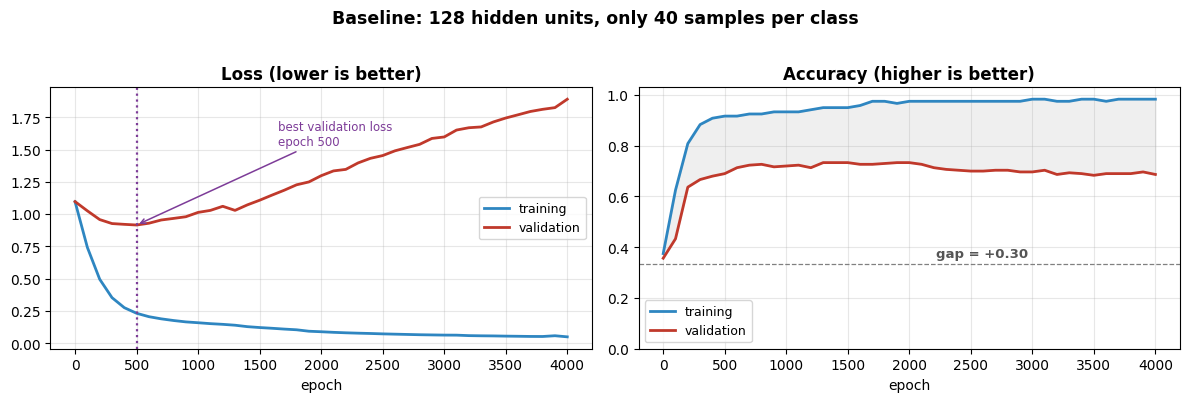

In [5]:
t0 = time.time()
baseline = make_network()
history_baseline = train(baseline, Optimizer_Adam())
tl, ta = evaluate(baseline, X_train, y_train)
vl, va = evaluate(baseline, X_val, y_val)

print(f"training   : loss {tl:.3f}   accuracy {ta:.3f}")
print(f"validation : loss {vl:.3f}   accuracy {va:.3f}")
print(f"gap        : {ta - va:+.3f}                    ({time.time() - t0:.1f}s)")

fig = draw_overfitting_curves(history_baseline,
                              "Baseline: 128 hidden units, only 40 samples per class")
plt.show()

Look at the **left** panel, not the right.

Training loss falls all the way to nearly zero. Validation loss falls for a few hundred epochs,
reaches its lowest point, and then **climbs for the rest of training.** Everything after that
dotted line made the model *worse* at its actual job.

That is overfitting seen properly. A single final number would have hidden it.

> **A free regularizer: early stopping.** If validation loss bottoms out at epoch 500, you could
> simply stop there — or keep the weights from that epoch. It costs nothing and is one of the most
> used tricks in practice. NNFS mentions it; we will not implement it today.


---
---
# Stage 3 · Build the tools

## Idea 3 — L2 and L1: charge rent for large weights

Look again at a network that has memorised its data: some of its weights are **enormous**. Large
weights let the output swing wildly between nearby inputs, which is exactly how you carve a tight
island around one training point.

So we charge for them. Add a penalty to the loss that grows with the size of the weights:

```
L2 penalty  =  lambda * sum(weights ** 2)       <- punishes LARGE weights hardest
L1 penalty  =  lambda * sum(abs(weights))       <- punishes every weight equally
```

`lambda` is the strength — a small number like 0.0005 — and it is a hyperparameter you tune on
the **validation** set.

Because the penalty is part of the loss, it must also appear in the **gradient**:

```
L2 gradient  =  2 * lambda * weights            <- bigger weights, bigger push back
L1 gradient  =  lambda * sign(weights)          <- a constant push towards zero
```

That difference matters. L2's push shrinks as a weight approaches zero, so weights get *small* but
rarely vanish. L1's push is the same size all the way down, so it drives many weights to **exactly
zero** — it performs a kind of feature selection. L2 is the usual default.


### Exercise 2 — penalties in the loss and in the gradient

Two parts. `regularization_loss` adds the penalty to the reported loss. `add_regularizer_gradients`
adds its derivative to `dweights` and `dbiases` — it is already called inside `Layer_Dense.backward`.


In [6]:
def regularization_loss(layer):
    """The penalty this layer adds to the loss."""
    total = 0.0
    if layer.weight_regularizer_l1 > 0:
        # TODO: lambda * sum of |weights|
        total += layer.weight_regularizer_l1 * np.sum(np.abs(layer.weights))
    if layer.weight_regularizer_l2 > 0:
        # TODO: lambda * sum of weights squared
        total += layer.weight_regularizer_l2 * np.sum(layer.weights ** 2)
    if layer.bias_regularizer_l1 > 0:
        total += layer.bias_regularizer_l1 * np.sum(np.abs(layer.biases))
    if layer.bias_regularizer_l2 > 0:
        total += layer.bias_regularizer_l2 * np.sum(layer.biases ** 2)
    return total


def add_regularizer_gradients(layer):
    """Add the penalty's derivative to the layer's gradients."""
    if layer.weight_regularizer_l1 > 0:
        # TODO: lambda * sign(weights).  np.sign gives -1, 0 or +1
        layer.dweights += layer.weight_regularizer_l1 * np.sign(layer.weights)
    if layer.weight_regularizer_l2 > 0:
        # TODO: 2 * lambda * weights
        layer.dweights += 2 * layer.weight_regularizer_l2 * layer.weights
    if layer.bias_regularizer_l1 > 0:
        layer.dbiases += layer.bias_regularizer_l1 * np.sign(layer.biases)
    if layer.bias_regularizer_l2 > 0:
        layer.dbiases += 2 * layer.bias_regularizer_l2 * layer.biases


# --- self-check ---
L = Layer_Dense(2, 3, weight_regularizer_l2=0.5)
L.weights = np.array([[1.0, -2.0, 3.0], [0.0, 1.0, -1.0]])
assert np.isclose(regularization_loss(L), 0.5 * 16.0), "L2 loss = lambda * sum of squares"

L.inputs = np.zeros((1, 2)); L.backward(np.zeros((1, 3)))
assert np.allclose(L.dweights, 2 * 0.5 * L.weights), "L2 gradient = 2 * lambda * weights"

L1 = Layer_Dense(2, 3, weight_regularizer_l1=0.1)
L1.weights = np.array([[1.0, -2.0, 3.0], [0.0, 1.0, -1.0]])
assert np.isclose(regularization_loss(L1), 0.1 * 8.0), "L1 loss = lambda * sum of |weights|"
L1.inputs = np.zeros((1, 2)); L1.backward(np.zeros((1, 3)))
assert np.allclose(L1.dweights, 0.1 * np.sign(L1.weights)), "L1 gradient = lambda * sign"

plain = Layer_Dense(2, 3)
assert regularization_loss(plain) == 0.0, "no regularizer means no penalty"
print("Exercise 2 passed")

Exercise 2 passed


Now see what each penalty actually does to the weights. Three identical networks, trained
with no penalty, with L1, and with L2.

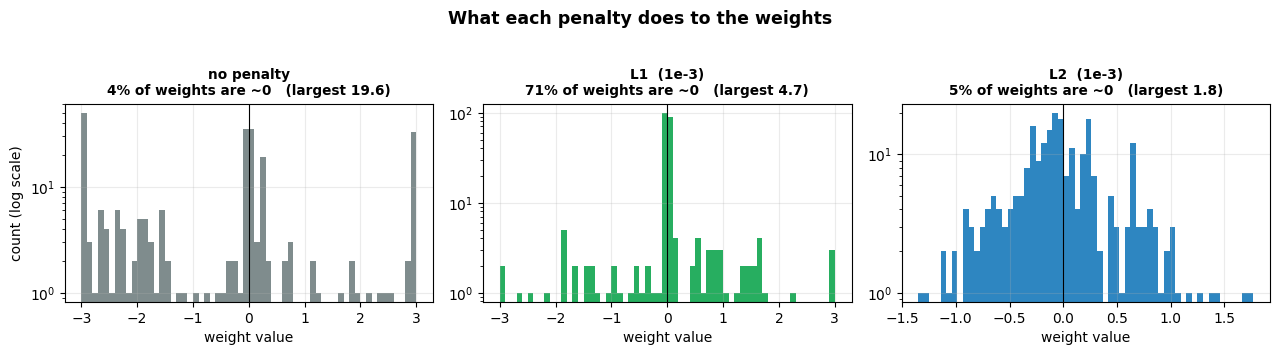

In [7]:
weight_sets = {}
for name, kwargs in [("no penalty", {}), ("L1  (1e-3)", {"l1": 1e-3}), ("L2  (1e-3)", {"l2": 1e-3})]:
    n = make_network(**kwargs)
    train(n, Optimizer_Adam(), epochs=4000, log_every=4000)
    weight_sets[name] = n["dense1"].weights

fig = draw_weight_histograms(weight_sets)
plt.show()

Read the three titles.

**No penalty**: the largest weight is about **19**. Those are the huge weights that let the
network carve islands around single points.

**L1**: about **70%** of the weights are essentially zero. The network has switched most of them
off and kept a few. That is why L1 is described as producing *sparse* models.

**L2**: few weights are exactly zero, but the largest is now under **2**. L2 shrank everything
rather than deleting anything.

Same goal, different shapes. L2 is the usual default; L1 is useful when you want a small, sparse
model or want to see which inputs matter.


---
## Idea 4 — Dropout: train a different network every step

Dropout (NNFS Ch. 15) is a stranger idea. On every training step, **randomly switch off a fraction
of the neurons** — set their outputs to zero.

Why on earth would that help? Two ways to see it:

* **No neuron can rely on a particular partner.** If a neuron's favourite collaborator might
  vanish at any moment, it has to learn something useful on its own. That discourages the fragile,
  co-adapted arrangements that memorise training points.
* **It is an ensemble.** Each step trains a slightly different thinned network, and at test time
  you effectively average over all of them.

### The scaling detail that everyone gets wrong

If you switch off 20% of neurons during training, the layer's total output is about 20% smaller
than it would be at test time, when everything is on. The network would see a different scale in
training than in use.

The fix is **inverted dropout**: divide the surviving outputs by the keep rate, so the expected
total stays the same.

```
keep_rate = 1 - dropout_rate
mask      = random 0/1 with probability keep_rate, divided by keep_rate
output    = inputs * mask
```

And the rule that follows from all of this: **dropout is ON during training and OFF at test
time.** Always.


### Exercise 3 — the dropout layer

`np.random.binomial(1, keep_rate, size=shape)` gives an array of 0s and 1s.


In [8]:
class Layer_Dropout:

    def __init__(self, rate):
        self.rate = 1 - rate          # store the KEEP rate: rate=0.2 -> keep 0.8

    def forward(self, inputs, training=True):
        self.inputs = inputs
        if not training:
            # TODO: at test time dropout does nothing at all
            self.output = inputs.copy()
            self.binary_mask = None
            return
        # TODO: random 0/1 mask, then divide by self.rate (inverted dropout)
        self.binary_mask = np.random.binomial(1, self.rate, size=inputs.shape) / self.rate
        # TODO: apply it
        self.output = inputs * self.binary_mask

    def backward(self, dvalues):
        if self.binary_mask is None:
            self.dinputs = dvalues
        else:
            # TODO: the gradient only flows through neurons that survived
            self.dinputs = dvalues * self.binary_mask


# --- self-check ---
np.random.seed(0)
d = Layer_Dropout(0.2)
x = np.ones((1000, 10))

d.forward(x, training=True)
killed = np.mean(d.output == 0)
assert 0.1 < killed < 0.3, f"about 20% of values should be zeroed, got {killed:.1%}"
assert abs(d.output.mean() - 1.0) < 0.05, \
    "inverted dropout: the AVERAGE should stay about 1.0 - did you divide by the keep rate?"

d.forward(x, training=False)
assert np.array_equal(d.output, x), "at test time dropout must change nothing"

d.forward(x, training=True)
d.backward(np.ones((1000, 10)))
assert np.array_equal(d.dinputs == 0, d.output == 0), \
    "the gradient must be blocked exactly where the neuron was switched off"
print("Exercise 3 passed")
print(f"\ntraining : {killed:.1%} of outputs zeroed, mean still {d.output.mean():.3f}")

Exercise 3 passed

training : 19.7% of outputs zeroed, mean still 0.998


### Checkpoint 1

1. You use `Layer_Dropout(0.3)`. What fraction of neurons survive each training step?
2. Why must dropout be switched off when you evaluate the model?
3. Why do we divide by the keep rate during training?


> **Your answers:**
>
> 1. **70%** survive. `Layer_Dropout(0.3)` switches off 30% of the neurons, so the keep rate is `1 - 0.3 = 0.7`.
> 2. At test time we want the network's real, stable answer, using all of its neurons. If dropout stayed on, random neurons would be switched off and the same input could give different predictions each time.
> 3. When neurons are switched off the layer's total output gets smaller than it will be at test time. Dividing by the keep rate scales the survivors up, so the expected total stays the same and the network sees the same scale in training and in use.


---
## Idea 5 — Where did `0.01 * randn` come from?

Since Lab 1 every weight matrix has started as `0.01 * np.random.randn(...)`, and nobody said why.
Here is why it matters.

When a signal passes through a layer it gets multiplied by the weights. Through many layers, those
multiplications compound — exactly the effect you saw with RNNs in Lab 4.

* weights **too small** → the signal shrinks at every layer until it vanishes,
* weights **too large** → it grows until it explodes,
* weights **just right** → it keeps roughly the same size all the way down.

"Just right" has a formula. For a layer with `n` inputs feeding into ReLU, **He initialisation**
uses a standard deviation of `sqrt(2 / n)`. (Xavier/Glorot initialisation, `sqrt(1 / n)`, is the
version for tanh and sigmoid.) The `2` is there because ReLU throws away the negative half of the
signal, so the surviving half has to be made bigger to compensate.


### Exercise 4 — measure it

Push random data through a 10-layer network three times, with three initialisation scales, and
record how big the activations are at each layer.


too small          layer 0: 9.95e-01   layer 10: 1.92e-11
just right (He)    layer 0: 9.95e-01   layer 10: 1.78e+00
too large          layer 0: 9.95e-01   layer 10: 1.92e+09


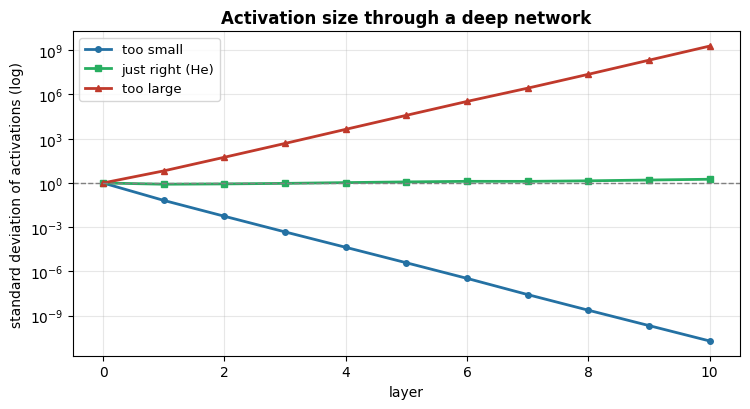

Exercise 4 passed


In [9]:
def activation_sizes(scale_mode, n_layers=10, width=128, seed=0):
    """Standard deviation of the activations after each layer."""
    rng = np.random.RandomState(seed)
    a = rng.randn(500, width)
    sizes = [a.std()]
    for _ in range(n_layers):
        if scale_mode == "too small":
            scale = 0.01
        elif scale_mode == "just right (He)":
            # TODO: He initialisation for ReLU: sqrt(2 / number of inputs)
            scale = np.sqrt(2 / width)
        else:
            scale = 1.0
        W = rng.randn(width, width) * scale
        a = np.maximum(0, a @ W)              # a dense layer followed by ReLU
        sizes.append(a.std())
    return sizes


curves = {name: activation_sizes(name)
          for name in ["too small", "just right (He)", "too large"]}

for name, vals in curves.items():
    print(f"{name:18s} layer 0: {vals[0]:.2e}   layer 10: {vals[-1]:.2e}")

fig = draw_init_depth(curves)
plt.show()

# --- self-check ---
assert curves["too small"][-1] < 1e-6, "with scale 0.01 the signal should vanish"
assert curves["too large"][-1] > 1e6, "with scale 1.0 it should explode"
assert 0.1 < curves["just right (He)"][-1] < 10, \
    "He initialisation should keep the signal about the same size - check sqrt(2 / width)"
print("Exercise 4 passed")

By layer 10 the small initialisation has shrunk the signal to about **1e-11** and the large one
has blown it up to about **1e+9**. He initialisation stays near 1 the whole way.

So `0.01` was fine for our two-layer networks and would be a disaster in a deep one. Every
framework uses a formula like He or Xavier by default — you will see it in Labs 7 and 8.


---
## Idea 6 — Batch normalisation

Good initialisation gets the activations to a sensible size **at the start**. But training changes
the weights, so the sizes drift as you go. **Batch normalisation** (Ioffe & Szegedy, 2015) fixes
them continuously, by normalising inside the network.

For each feature, across the current batch:

```
mean      = average of this feature over the batch
variance  = its variance over the batch
x_hat     = (x - mean) / sqrt(variance + epsilon)      <- now mean 0, std 1
output    = gamma * x_hat + beta                       <- learned scale and shift
```

The last line matters. Forcing every layer to mean 0 and standard deviation 1 would be too
restrictive, so batch norm gives the network two **learnable** parameters per feature to undo the
normalisation if that turns out to be useful. The network decides.

Benefits, in rough order of how much people agree on them: training is faster and tolerates larger
learning rates; it is less sensitive to initialisation; and it has a mild regularising effect,
because each sample's normalisation depends on whichever other samples share its batch. (*Why* it
works so well is still debated — the original "internal covariate shift" explanation is disputed.)

> **What we are building.** The **forward pass only**. Batch norm's backward pass is the most
> involved derivation in this course, and frameworks write it for you — you will use
> `BatchNormalization` in Labs 7–8. The idea lives in the forward pass.


### Exercise 5 — batch norm forward

Use `axis=0` throughout: statistics are taken **per feature, across the batch**.


Exercise 5 passed

before : mean +7.04   std 2.97
after  : mean -0.00   std 1.00
gamma=2, beta=5 : mean +5.00   std 2.00


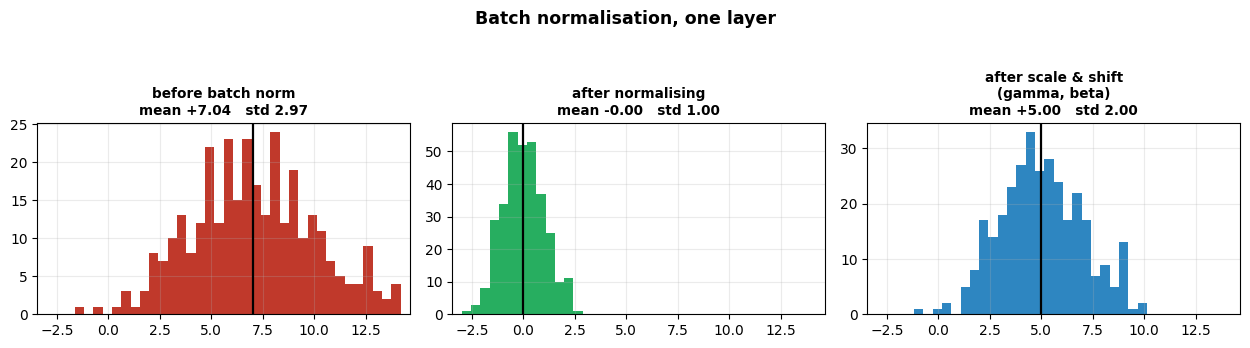

In [10]:
def batchnorm_forward(z, gamma=1.0, beta=0.0, epsilon=1e-7):
    """Normalise each feature across the batch, then scale and shift."""
    # TODO: mean and variance of each FEATURE across the batch (axis=0)
    mean = np.mean(z, axis=0)
    variance = np.var(z, axis=0)

    # TODO: normalise
    z_hat = (z - mean) / np.sqrt(variance + epsilon)

    # TODO: scale and shift
    return gamma * z_hat + beta


# --- self-check ---
rng = np.random.RandomState(0)
z = rng.randn(64, 5) * 3.0 + 7.0          # badly scaled: mean about 7, std about 3

out = batchnorm_forward(z)
assert out.shape == z.shape
assert np.allclose(out.mean(axis=0), 0, atol=1e-5), "each feature should end with mean 0"
assert np.allclose(out.std(axis=0), 1, atol=1e-3), "each feature should end with std 1"

scaled = batchnorm_forward(z, gamma=2.0, beta=5.0)
assert np.allclose(scaled.mean(axis=0), 5.0, atol=1e-5), "beta sets the new mean"
assert np.allclose(scaled.std(axis=0), 2.0, atol=1e-3), "gamma sets the new std"
print("Exercise 5 passed")

print(f"\nbefore : mean {z.mean():+.2f}   std {z.std():.2f}")
print(f"after  : mean {out.mean():+.2f}   std {out.std():.2f}")
print(f"gamma=2, beta=5 : mean {scaled.mean():+.2f}   std {scaled.std():.2f}")

fig = draw_batchnorm_effect(z, out, scaled)
plt.show()

### Checkpoint 2

1. Why does He initialisation use `sqrt(2 / n)` rather than `sqrt(1 / n)` for a ReLU network?
2. Batch norm forces mean 0 and standard deviation 1 — so what are `gamma` and `beta` for?
3. Name one thing initialisation and batch normalisation have in common.


> **Your answers:**
>
> 1. ReLU sets every negative value to zero, so only about half of the signal survives. The extra factor of 2 makes the weights bigger to make up for the half that was thrown away, so the signal keeps the same size from layer to layer.
> 2. Forcing every layer to mean 0 and std 1 would be too restrictive. `gamma` (scale) and `beta` (shift) are learned, so the network can undo the normalisation if that works better for it.
> 3. Both try to keep the activations at a sensible size so the signal does not vanish or explode as it goes through many layers. Initialisation does it once at the start, and batch norm keeps doing it during training.


---
---
# Stage 4 · Prove it

# Assessment


Four networks, identical except for regularization. Same data, same optimizer, same 4,000 epochs.
The whole thing runs in about ten seconds.

Watch the **gap** between training and validation, not just the accuracy.


### Q1 — The showdown

In [11]:
configs = {
    "baseline":      {},
    "L2 (5e-4)":     {"l2": 5e-4},
    "dropout (0.2)": {"dropout_rate": 0.2},
    "L2 + dropout":  {"l2": 5e-4, "dropout_rate": 0.2},
}

results, nets, histories = {}, {}, {}
t0 = time.time()
for name, kwargs in configs.items():
    # TODO: build the network with these settings, train it with Adam,
    #       and store the network and its history
    net = make_network(**kwargs)
    hist = train(net, Optimizer_Adam())
    nets[name], histories[name] = net, hist

    # TODO: record (train accuracy, validation accuracy, validation loss)
    train_loss, train_acc = evaluate(net, X_train, y_train)
    val_loss, val_acc = evaluate(net, X_val, y_val)
    results[name] = (train_acc, val_acc, val_loss)

print(f"{'model':<16} {'train acc':>10} {'val acc':>9} {'val loss':>10} {'gap':>8}")
print("-" * 58)
for name, (ta, va, vl) in results.items():
    print(f"{name:<16} {ta:>10.3f} {va:>9.3f} {vl:>10.3f} {ta - va:>+8.3f}")
print(f"\n({time.time() - t0:.0f} seconds)")

# --- self-check ---
assert len(results) == 4
base_gap = results["baseline"][0] - results["baseline"][1]
for name in ["L2 (5e-4)", "dropout (0.2)", "L2 + dropout"]:
    gap = results[name][0] - results[name][1]
    assert gap < base_gap, f"{name} should shrink the gap"
    assert results[name][2] < results["baseline"][2], f"{name} should lower validation loss"
assert results["L2 (5e-4)"][1] > results["baseline"][1], "L2 should improve validation accuracy"
print("Q1 passed")

model             train acc   val acc   val loss      gap
----------------------------------------------------------
baseline              0.983     0.687      1.890   +0.297
L2 (5e-4)             0.975     0.727      0.970   +0.248
dropout (0.2)         0.867     0.647      1.446   +0.220
L2 + dropout          0.833     0.660      1.181   +0.173

(3 seconds)
Q1 passed


### Q2 — Look at what they learned

Draw the decision boundaries, and the baseline's curves beside L2's.


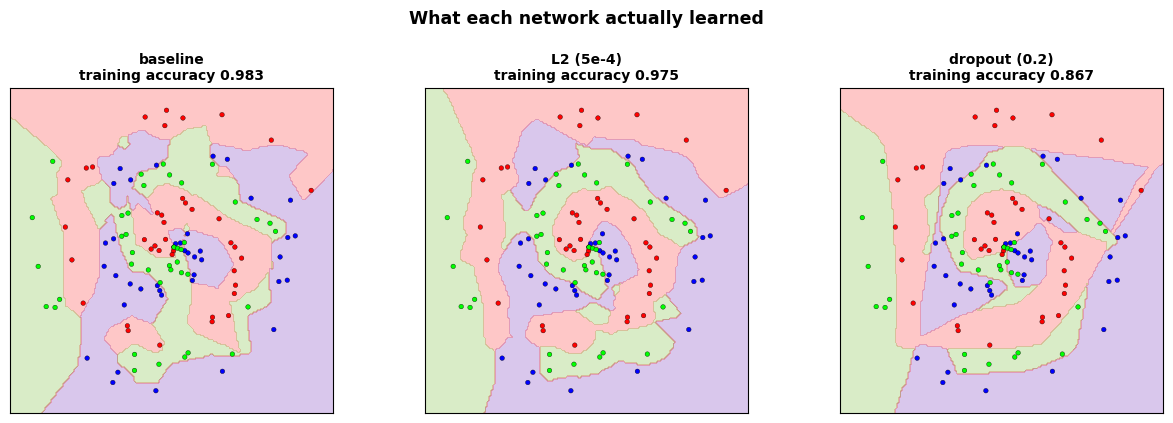

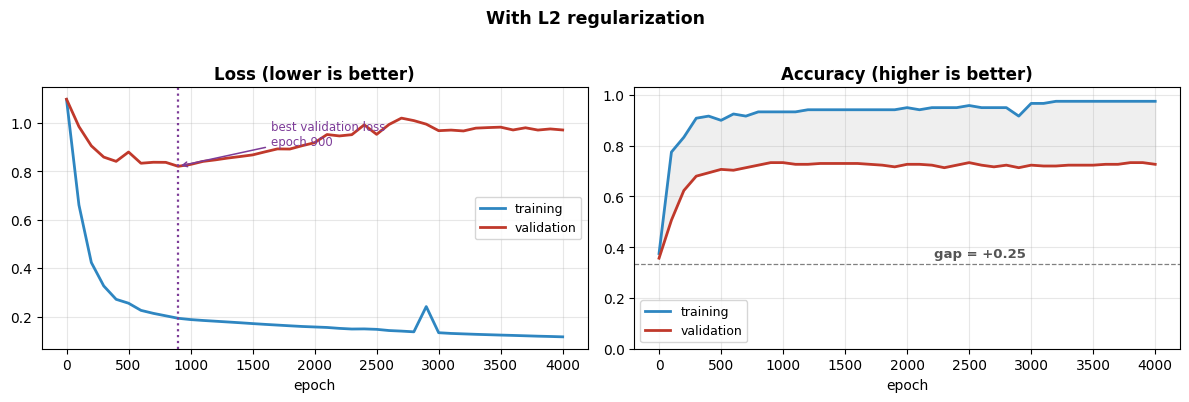

In [12]:
def predictor(net):
    def f(points):
        forward(net, points, np.zeros(len(points), dtype=int), training=False)
        return np.argmax(net["loss_activation"].output, axis=1)
    return f


# TODO: decision boundaries for the baseline, L2 and dropout networks
fig = draw_decision_boundaries({"baseline": predictor(nets["baseline"]),
                                "L2 (5e-4)": predictor(nets["L2 (5e-4)"]),
                                "dropout (0.2)": predictor(nets["dropout (0.2)"])},
                               X_train, y_train)
plt.show()

# TODO: the overfitting curves for the L2 network, to compare with the baseline above
fig = draw_overfitting_curves(histories["L2 (5e-4)"], "With L2 regularization")
plt.show()

---

## What you built today

| Tool | You wrote | What it does |
|---|---|---|
| **L2** | `regularization_loss`, `add_regularizer_gradients` | shrinks every weight; largest weight fell from 19 to under 2 |
| **L1** | the same functions | drives about 70% of weights to zero |
| **Dropout** | `Layer_Dropout` | trains a different thinned network every step |
| **Initialisation** | `activation_sizes` | keeps activations from vanishing or exploding |
| **Batch norm** | `batchnorm_forward` | re-centres activations during training |

And the lesson that is easy to say and hard to accept: **a regularised model fits its training
data worse on purpose.** Training accuracy is not the goal.

### What was simplified

* **Batch norm's backward pass** was skipped, so we did not train with it. Frameworks provide it.
* **Early stopping** was described but not implemented.
* **Only one regularization strength** was tuned per method. In practice you would search.
* **Dropout had little room to help** on a network this small. On large models it is one of the
  most effective tools there is.

### Next week

**Lab 7** leaves NumPy behind. Everything you have built by hand — layers, activations, losses,
optimizers, regularizers — exists in **TensorFlow** as one line each. Knowing what those lines do
is why we built them first.

### Before next week

* Restart the kernel and run everything top to bottom. Every assertion should pass.
* Keep this notebook.
* Read NNFS Chapters 14 and 15 alongside your code.

---

### Submission

1. Create a new repository on GitHub for this course and name it `arti402`.
2. Rename this file to `arti402_Lab6_<YourID>.ipynb` and upload the completed notebook, with all
   outputs visible, to your repository.
